# CodeInsight AI
## Fast Prompting en Acción

### Asistente Inteligente para la Revisión Final de Proyectos Web mediante Prompt Engineering

**Proyecto:** CodeInsight AI  
**Caso de estudio:** Tienda Cool  
**Estudiante:** Ivanna Micaela Arzamendia  
**Curso:** Inteligencia Artificial: Generación de Prompts  

---

### Objetivo de la POC

Esta notebook implementa una prueba de concepto de CodeInsight AI utilizando técnicas de Fast Prompting para analizar código perteneciente a un proyecto web.

Se experimentará con diferentes configuraciones de prompts para comparar sus resultados y evaluar cómo el uso de contexto, roles, restricciones y formatos de salida mejora la precisión y utilidad de las respuestas generadas por Inteligencia Artificial.


In [1]:
!pip install -q groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 1.2 MB/s eta 0:00:00


In [3]:
from groq import Groq
from getpass import getpass

api_key = getpass("IA gen de promps")

client = Groq(api_key=api_key)

print("Cliente de Groq configurado correctamente.")

IA gen de promps··········
Cliente de Groq configurado correctamente.


In [7]:
MODELO = "openai/gpt-oss-20b"

respuesta = client.chat.completions.create(
    model=MODELO,
    messages=[
        {
            "role": "system",
            "content": "Eres un asistente especializado en desarrollo web."
        },
        {
            "role": "user",
            "content": "Respondé solamente con la frase: CodeInsight AI conectado correctamente."
        }
    ],
    temperature=0.2,
    max_completion_tokens=50
)

print(respuesta.choices[0].message.content)

CodeInsight AI conectado correctamente


In [39]:
def consultar_ia(prompt, sistema=""):
    """
    Envía un prompt al modelo y devuelve únicamente la respuesta final.
    """

    instrucciones = f"{sistema}\n\n{prompt}" if sistema else prompt

    respuesta = client.chat.completions.create(
        model=MODELO,
        messages=[
            {
                "role": "user",
                "content": instrucciones
            }
        ],
        temperature=0.6,
        max_completion_tokens=5000,
        reasoning_effort="low",
        include_reasoning=False
    )

    return respuesta.choices[0].message.content


## 1. Caso de estudio: Tienda Cool

Para evaluar el funcionamiento de CodeInsight AI se utilizará como caso de estudio Tienda Cool, una aplicación web de comercio electrónico desarrollada con PHP, HTML, CSS y JavaScript.

En esta primera prueba se analizará un fragmento real del código fuente del proyecto mediante dos configuraciones diferentes de prompts:

1. Un prompt básico y general.
2. Un prompt optimizado aplicando técnicas de Fast Prompting.

El objetivo será comparar los resultados obtenidos y analizar cómo la estructura del prompt influye en la calidad de la respuesta generada por el modelo.

In [51]:
codigo_tienda_cool = r'''

<?php include('header.php'); ?>
// 1) Conexion
// a) realizar la conexion con la bbdd
// b) seleccionar la base de datos a usar
$conexion=mysqli_connect("127.0.0.1","root","");
mysqli_select_db($conexion,"tiendapro");
// 2) Almacenamos los datos del envío GET
// a) generar variables para el id a utilizar
$id = $_GET['id'];
// 3) Preparar la SQL
// => Selecciona todos los campos de la tabla alumno donde el campo id  sea igual a $id
// a) generar la consulta a realizar
$consulta = "SELECT * FROM tipo de prenda WHERE id=$id";
// 4) Ejecutar la orden y almacenamos en una variable el resultado
// a) ejecutar la consulta
$repuesta=mysqli_query ($conexion, $consulta);
// 5) Transformamos el registro obtenido a un array
$datos=mysqli_fetch_array($repuesta);
?>

<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <meta http-equiv="X-UA-Compatible" content="IE=edge">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>Tienda de Ropa</title>
  <!-- Core theme CSS (includes Bootstrap)-->
  <link href="css/styles.css" rel="stylesheet" />
</head>
<body>

  <header>
    <h1>Detalle del producto</h1>
  </header>
  <?php
  // 6) asignamos a diferentes variables los respectivos valores del array $datos.
  // este paso no es estrictamente necesario, pero es mas practico
  //para despues llamarlos solo con el nombre de la variable
  $prenda=$datos["prenda"];
  $marca=$datos["marca"];
  $talle=$datos["talle"];
  $precio=$datos["precio"];
  $imagen=$datos['imagen'];
  $pago=$datos['pago'];
  ?>

  <!-- mostramos los datos de ese único producto
  lo meto en una card, pero se puede mostrar como quieran-->

  <div class="container">
    <div class="row">
      <div class="card w-50">
        <img class="card-img-top" src="data:image/jpg;base64, <?php echo base64_encode($imagen)?>" alt="..." />
        <img class="card-img-top" src="<?php echo ($datos['imagen2'])?>" alt="..." />

        <div class="card-body">
          <h5 class="card-title">Marca: <?php echo $marca;?></h5>
          <p class="card-text">Talle: <?php echo $talle?></p>
          <p class="card-text">$<?php echo $precio;?></p>
          <br>
          <div class="">


            <?php echo $pago; ?>
            <br>
            <br>
            <br>
            <a href="agregarcliente.php?id=<?php echo $datos['id'];?>"> <button type="button"
            name="button">registra al cliente antes de la comprar</button></a>
          </div>
          <!-- si quieren pueden agregar el link o un boton de pago de Mercadopago
          <a href="<?php// echo $reg['link']; ?>" class="btn btn-primary">Comprar</a> -->
        </div>
      </div>
    </div>
  </div>

  <footer>
    <br>
    <h2>footer</h2>
  </footer>


  <!-- Bootstrap core JS-->
  <script src="https://cdn.jsdelivr.net/npm/bootstrap@5.1.3/dist/js/bootstrap.bundle.min.js"></script>
  <!-- Core theme JS-->



  <script src="js/scripts.js"></script>
</body>
</html>

<?php include('footer.php'); ?>


'''

print("Código cargado correctamente.")
print("Cantidad de caracteres:", len(codigo_tienda_cool))


Código cargado correctamente.
Cantidad de caracteres: 2994


## 2. Prueba 1: Prompt básico

En esta primera prueba se utilizará una instrucción simple y poco estructurada. El objetivo es observar qué tipo de respuesta genera el modelo cuando recibe poco contexto y no se especifica un formato de salida.

Este resultado servirá como punto de comparación para evaluar posteriormente un prompt optimizado mediante técnicas de Fast Prompting.

In [52]:
prompt_basico = f"""
Revisa el siguiente código y dime si se puede mejorar:

{codigo_tienda_cool}
"""

resultado_basico = consultar_ia(prompt_basico)

print("=== RESULTADO DEL PROMPT BÁSICO ===\n")
print(resultado_basico)

=== RESULTADO DEL PROMPT BÁSICO ===

## 1. Resumen rápido

El script que has pegado hace lo siguiente:

1. Conecta a MySQL (con `mysqli_connect`).
2. Lee un `id` de la URL (`$_GET['id']`).
3. Ejecuta una consulta `SELECT * FROM tipo de prenda WHERE id=$id`.
4. Convierte el resultado en un array y extrae los campos.
5. Muestra la información en una tarjeta de Bootstrap.

En general funciona, pero hay varios puntos de mejora, tanto en **seguridad** (inyección SQL, validación de entrada, manejo de errores) como en **legibilidad** (estructura del código, uso de funciones, separación de responsabilidades, estilo de PHP, etc.).

A continuación te dejo una propuesta paso a paso con explicaciones y código de ejemplo.

---

## 2. Mejoras de seguridad

| Problema | Solución | Código de ejemplo |
|----------|----------|-------------------|
| **Inyección SQL**: concatenas `$id` directamente en la consulta. | Usa **consultas preparadas** (`mysqli_prepare`) o PDO con `bind_param`. | ```php<br>$stmt 

## 3. Prueba 2: Prompt optimizado con Fast Prompting

En esta segunda prueba se utilizará un prompt estructurado aplicando técnicas de Fast Prompting.

A diferencia del prompt básico, se incorporarán:

- un rol específico para el modelo;
- contexto sobre el proyecto;
- un objetivo claramente definido;
- criterios concretos de análisis;
- restricciones sobre la cantidad de resultados;
- un formato de salida establecido.

El objetivo es evaluar si una instrucción más precisa permite obtener una respuesta más organizada, relevante y aplicable al proyecto.

In [53]:
prompt_optimizado = f"""
Contexto:
El siguiente código pertenece a Tienda Cool, una aplicación web de comercio
electrónico desarrollada con PHP, HTML, CSS y JavaScript.

Objetivo:
Realizar una revisión técnica del código antes de su publicación.

Analiza exclusivamente los siguientes aspectos:

1. Calidad y organización del código.
2. Posibles errores de programación.
3. Seguridad.
4. Rendimiento.
5. Mantenibilidad.

Para cada problema detectado indica:

- Hallazgo
- Categoría
- Prioridad: Alta, Media o Baja
- Explicación breve
- Recomendación concreta

Restricciones:
- Selecciona únicamente los 5 hallazgos más importantes.
- Evita recomendaciones genéricas.
- No inventes problemas que no puedan inferirse del código.
- Utiliza un lenguaje técnico pero fácil de comprender.
- Prioriza los problemas que puedan afectar la seguridad o el funcionamiento.

Código a analizar:

{codigo_tienda_cool}
"""

resultado_optimizado = consultar_ia(
    prompt_optimizado,
    sistema="""Actúa como un desarrollador web senior especializado en PHP,
    revisión de código y buenas prácticas de seguridad."""
)

print("=== RESULTADO DEL PROMPT OPTIMIZADO ===\n")
print(resultado_optimizado)

=== RESULTADO DEL PROMPT OPTIMIZADO ===

## Hallazgos – Tienda Cool (Revisión de código PHP)

| Hallazgo | Categoría | Prioridad | Explicación breve | Recomendación concreta |
|----------|-----------|-----------|-------------------|------------------------|
| 1 | **Seguridad – Inyección SQL** | Alta | La consulta se construye concatenando directamente `$_GET['id']` sin sanitizar. Si un atacante envía `id=1 OR 1=1`, la sentencia se convierte en `SELECT * FROM tipo de prenda WHERE id=1 OR 1=1` y devuelve todos los registros. | Utilizar **sentencias preparadas** (`mysqli_prepare` / `PDO`) y enlazar el parámetro como entero (`int`). Ejemplo: ` $stmt = $conexion->prepare('SELECT * FROM tipo_de_prenda WHERE id = ?'); $stmt->bind_param('i', $id);`. Además, validar que `id` sea un número entero antes de usarlo. |
| 2 | **Seguridad – Exposición de datos binarios** | Media | La imagen se envía en la respuesta como base64 dentro de un atributo `src`. Si la imagen contiene datos binarios que no so

## 4. Comparación de resultados

Luego de ejecutar ambas configuraciones, se compararon los resultados obtenidos.

El prompt básico logró detectar diferentes problemas presentes en el código, pero la respuesta fue más extensa y menos uniforme en su organización.

En cambio, el prompt optimizado permitió definir previamente el rol del modelo, el contexto del proyecto, los aspectos específicos a analizar, la cantidad máxima de hallazgos y el formato esperado de la respuesta.

Esto permitió obtener una salida más estructurada, priorizada y fácil de interpretar.

In [54]:
import pandas as pd

comparacion = pd.DataFrame({
    "Criterio": [
        "Contexto del proyecto",
        "Rol definido",
        "Criterios de análisis",
        "Priorización",
        "Formato estructurado",
        "Cantidad de hallazgos controlada",
        "Facilidad de interpretación"
    ],
    "Prompt básico": [
        "No",
        "No",
        "No definidos",
        "Limitada",
        "Parcial",
        "No",
        "Media"
    ],
    "Prompt optimizado": [
        "Sí",
        "Sí",
        "5 criterios definidos",
        "Alta / Media / Baja",
        "Sí",
        "Máximo 5",
        "Alta"
    ]
})

comparacion

,Criterio,Prompt básico,Prompt optimizado
0,Contexto del proyecto,No,Sí
1,Rol definido,No,Sí
2,Criterios de análisis,No definidos,5 criterios definidos
3,Priorización,Limitada,Alta / Media / Baja
4,Formato estructurado,Parcial,Sí
5,Cantidad de hallazgos controlada,No,Máximo 5
6,Facilidad de interpretación,Media,Alta


## 5. Prompt Chaining: análisis de seguridad

Luego de obtener el análisis técnico optimizado, se reutilizará su resultado como entrada para una segunda etapa especializada en seguridad.

Esta técnica de Prompt Chaining permite dividir un problema complejo en tareas más pequeñas, donde la salida de un prompt se convierte en el contexto del siguiente.

Para optimizar el uso de la API, en esta etapa no se enviará nuevamente el código fuente completo. Se utilizarán únicamente los hallazgos obtenidos previamente, reduciendo la cantidad de información repetida y el consumo de tokens.


In [61]:
prompt_seguridad = f"""
A partir exclusivamente del análisis técnico generado en la etapa anterior,
realiza una revisión orientada a seguridad.

ANÁLISIS ANTERIOR:
{resultado_optimizado}

Tareas:

1. Identifica cuáles de los hallazgos están relacionados con seguridad.
2. Indica el riesgo que representa cada uno.
3. Relaciona los hallazgos con OWASP Top 10:2025 únicamente cuando corresponda.

   IMPORTANTE:
   - SQL Injection corresponde a A05:2025 – Injection.
   - Cross-Site Scripting (XSS) forma parte de A05:2025 – Injection.
   - No utilices numeraciones de versiones anteriores.
   - Si un hallazgo no puede asociarse claramente a una categoría OWASP Top 10:2025,
     indica "Sin correspondencia directa".
4. Asigna una prioridad: Alta, Media o Baja.
5. Propone una acción concreta para reducir el riesgo.

Formato de salida:

- Hallazgo
- Riesgo de seguridad
- Categoría OWASP relacionada, si corresponde
- Prioridad
- Recomendación

Restricciones:
- Utiliza solamente la información disponible en el análisis anterior.
- No inventes vulnerabilidades adicionales.
- No vuelvas a realizar un análisis general del código.
- Sé breve y concreto.
"""

resultado_seguridad = consultar_ia(
    prompt_seguridad,
    sistema="""Actúa como especialista en seguridad de aplicaciones web,
    desarrollo seguro y buenas prácticas OWASP."""
)

print("=== ANÁLISIS DE SEGURIDAD ===\n")
print(resultado_seguridad)

=== ANÁLISIS DE SEGURIDAD ===

**Hallazgo 1**  
- **Riesgo de seguridad**: Inyección SQL que permite al atacante leer, modificar o eliminar datos arbitrarios.  
- **Categoría OWASP relacionada**: A05:2025 – Injection  
- **Prioridad**: Alta  
- **Recomendación**: Usar sentencias preparadas (`mysqli_prepare`/`PDO`) y enlazar el parámetro como entero. Validar que `$_GET['id']` sea un número antes de usarlo. Ejemplo:  
  ```php
  $id = (int)$_GET['id'];
  $stmt = $conexion->prepare('SELECT * FROM tipo_de_prenda WHERE id = ?');
  $stmt->bind_param('i', $id);
  $stmt->execute();
  ```  

---

**Hallazgo 2**  
- **Riesgo de seguridad**: Exposición de datos binarios que pueden incluir código malicioso, provocando XSS o la ejecución de scripts en el navegador.  
- **Categoría OWASP relacionada**: A05:2025 – Injection (XSS)  
- **Prioridad**: Media  
- **Recomendación**: Servir la imagen como archivo físico con un controlador que verifique el MIME (`header('Content-Type: image/jpeg')`). Si se m

## 6. Generación del reporte ejecutivo

En esta etapa se utilizarán los resultados obtenidos durante el análisis técnico y de seguridad para generar un reporte ejecutivo.

El objetivo es transformar información técnica en un resumen claro y comprensible, permitiendo comunicar los principales hallazgos del proyecto a desarrolladores, docentes, clientes u otros perfiles no técnicos.

Para evitar consultas innecesarias, el modelo reutilizará los resultados generados en las etapas anteriores en lugar de analizar nuevamente el código fuente.

In [57]:
prompt_reporte = f"""
Genera un reporte ejecutivo utilizando únicamente la información obtenida
en las etapas anteriores de CodeInsight AI.

ANÁLISIS TÉCNICO:
{resultado_optimizado}

ANÁLISIS DE SEGURIDAD:
{resultado_seguridad}

El reporte debe contener:

1. Resumen general del estado del código.
2. Principales hallazgos detectados.
3. Riesgos de seguridad más relevantes.
4. Recomendaciones prioritarias.
5. Conclusión general.

Requisitos:
- Utiliza un lenguaje claro y profesional.
- Evita explicaciones excesivamente técnicas.
- No agregues problemas que no aparezcan en los análisis anteriores.
- Prioriza la información más importante.
- El reporte debe ser breve y fácil de interpretar.
"""

resultado_reporte = consultar_ia(
    prompt_reporte,
    sistema="""Actúa como analista técnico especializado en transformar
    resultados de desarrollo y seguridad en reportes ejecutivos claros."""
)

print("=== REPORTE EJECUTIVO DE CODEINSIGHT AI ===\n")
print(resultado_reporte)

=== REPORTE EJECUTIVO DE CODEINSIGHT AI ===

**Reporte Ejecutivo – Revisión de Código PHP (Tienda Cool)**  

| Elemento | Información |
|----------|-------------|
| **Proyecto** | Tienda Cool – Módulo de visualización de prendas |
| **Fecha** | 17‑08‑2026 |
| **Equipo de revisión** | CodeInsight AI |

---

### 1. Resumen General  
El análisis de la capa PHP que muestra los detalles de una prenda revela que la lógica básica funciona, pero existen vulnerabilidades y deficiencias de calidad que pueden comprometer la seguridad, el rendimiento y la mantenibilidad de la aplicación.  

---

### 2. Principales Hallazgos  

| Hallazgo | Categoría | Prioridad |
|----------|-----------|-----------|
| 1 | **Inyección SQL** (concatenación de `$_GET['id']`) | Alta |
| 2 | **Exposición de datos binarios** (imagen en base64 sin validación) | Media |
| 3 | **Nombres de tabla con espacios** (`tipo de prenda`) | Media |
| 4 | **Consulta sin índices** (`SELECT *`) | Baja |
| 5 | **Salida HTML sin escape**

## 7. Generación del backlog de mejoras

A partir de los resultados obtenidos en las etapas anteriores, CodeInsight AI generará un backlog de mejoras para organizar las acciones recomendadas.

El objetivo es transformar los hallazgos técnicos y de seguridad en tareas concretas que puedan ser implementadas en futuras versiones del proyecto.

Las tareas serán priorizadas según su impacto sobre la seguridad, el funcionamiento y la mantenibilidad de la aplicación.

In [58]:
prompt_backlog = f"""
Genera un backlog de mejoras para el proyecto Tienda Cool utilizando
únicamente los siguientes resultados obtenidos previamente.

ANÁLISIS TÉCNICO:
{resultado_optimizado}

ANÁLISIS DE SEGURIDAD:
{resultado_seguridad}

REPORTE EJECUTIVO:
{resultado_reporte}

Genera como máximo 5 tareas.

Para cada tarea indica:

- ID
- Tarea
- Origen del hallazgo
- Prioridad: Alta, Media o Baja
- Impacto esperado
- Acción recomendada

Ordena las tareas desde la prioridad más alta hasta la más baja.

Restricciones:
- No inventes nuevos problemas.
- Utiliza solamente los hallazgos existentes.
- Las tareas deben ser concretas y aplicables.
- Evita duplicar recomendaciones.
"""

resultado_backlog = consultar_ia(
    prompt_backlog,
    sistema="""Actúa como líder técnico de un equipo de desarrollo
    especializado en planificación y priorización de mejoras de software."""
)

print("=== BACKLOG DE MEJORAS DE CODEINSIGHT AI ===\n")
print(resultado_backlog)

=== BACKLOG DE MEJORAS DE CODEINSIGHT AI ===

**Backlog de Mejoras – Tienda Cool**  
*(ordenado por prioridad, máximo 5 tareas)*  

| ID | Tarea | Origen del hallazgo | Prioridad | Impacto esperado | Acción recomendada |
|----|-------|---------------------|-----------|------------------|--------------------|
| 1 | **Implementar sentencias preparadas y validación de `id`** | Hallazgo 1 (Inyección SQL) | Alta | Eliminación de la vulnerabilidad de inyección SQL; protección de datos sensibles y estabilidad de la BD. | Reescribir la consulta con `mysqli_prepare`/`PDO`, enlazar el parámetro como entero (`'i'`) y validar que `$_GET['id']` sea un número entero antes de usarlo. |
| 2 | **Escapar todas las salidas HTML** | Hallazgo 5 (XSS por salida sin escape) | Alta | Prevención de ataques XSS; protección de usuarios y reputación del sitio. | Envolver cada variable que se imprime en el HTML con `htmlspecialchars($var, ENT_QUOTES, 'UTF-8')`, incluyendo las variables de imagen base64. |
| 3 | **

## 8. Dashboard de resultados

Para complementar el análisis realizado por CodeInsight AI, se generará una representación visual de los principales hallazgos detectados.

En lugar de utilizar una API adicional de generación de imágenes, el dashboard será construido directamente con Python utilizando Matplotlib.

Esta decisión permite reducir costos y evitar consultas innecesarias a servicios externos, manteniendo la visualización dentro de la misma Jupyter Notebook.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

hallazgos = pd.DataFrame({
    "Hallazgo": [
        "SQL Injection",
        "Exposición de datos binarios",
        "Nombre de tabla con espacios",
        "Consulta SQL poco optimizada",
        "Salida HTML sin escape"
    ],
    "Categoría": [
        "Seguridad",
        "Seguridad",
        "Calidad y organización",
        "Rendimiento",
        "Mantenibilidad y seguridad"
    ],
    "Prioridad": [
        "Alta",
        "Media",
        "Media",
        "Baja",
        "Media"
    ]
})

hallazgos

,Hallazgo,Categoría,Prioridad
0,SQL Injection,Seguridad,Alta
1,Exposición de datos binarios,Seguridad,Media
2,Nombre de tabla con espacios,Calidad y organización,Media
3,Consulta SQL poco optimizada,Rendimiento,Baja
4,Salida HTML sin escape,Mantenibilidad y seguridad,Media


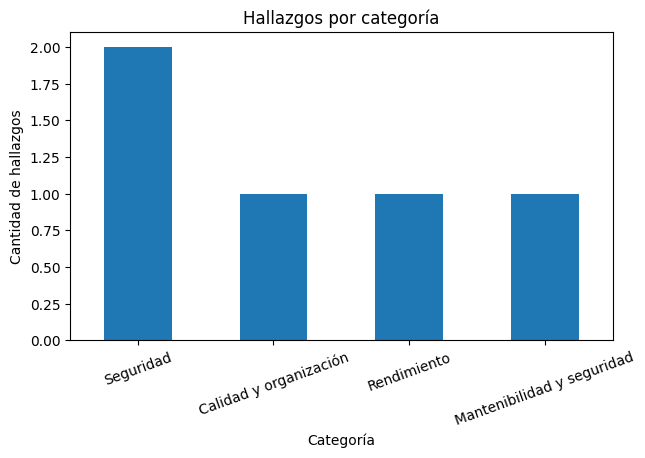

In [63]:
categorias = hallazgos["Categoría"].value_counts()

plt.figure(figsize=(7, 4))
categorias.plot(kind="bar")

plt.title("Hallazgos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=20)
plt.show()


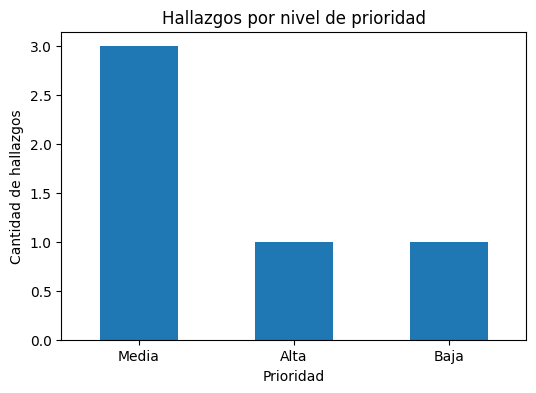

In [64]:
prioridades = hallazgos["Prioridad"].value_counts()

plt.figure(figsize=(6, 4))
prioridades.plot(kind="bar")

plt.title("Hallazgos por nivel de prioridad")
plt.xlabel("Prioridad")
plt.ylabel("Cantidad de hallazgos")
plt.xticks(rotation=0)
plt.show()

## 9. Optimización del uso de la API

Uno de los aspectos considerados durante la implementación de CodeInsight AI fue reducir la cantidad de consultas innecesarias al modelo de Inteligencia Artificial.

La POC fue diseñada utilizando Prompt Chaining, permitiendo reutilizar los resultados obtenidos en etapas anteriores en lugar de enviar nuevamente el código fuente completo en cada consulta.

Durante la ejecución se realizaron las siguientes consultas:

1. Prueba inicial de conexión con la API.
2. Ejecución del prompt básico.
3. Ejecución del prompt optimizado.
4. Análisis especializado de seguridad.
5. Generación del reporte ejecutivo.
6. Generación del backlog de mejoras.

La comparación de resultados y el dashboard fueron generados directamente con Python, sin realizar consultas adicionales a la API.

Este enfoque permite reducir información repetida, disminuir el consumo de tokens y optimizar el costo de ejecución de la solución.

## 10. Análisis de resultados

Los resultados obtenidos permiten observar diferencias claras entre el prompt básico y el prompt optimizado.

El prompt básico logró identificar problemas relevantes en el código, pero produjo una respuesta menos controlada y con una estructura determinada principalmente por el propio modelo.

Al aplicar técnicas de Fast Prompting, el resultado fue más organizado y específico. La incorporación de contexto, un rol definido, criterios de análisis, restricciones y un formato de salida permitió controlar mejor la respuesta generada.

Además, mediante Prompt Chaining fue posible reutilizar los resultados obtenidos para desarrollar nuevas etapas de análisis sin necesidad de procesar nuevamente el código fuente completo.

La POC demuestra que el diseño del prompt influye directamente en la calidad, claridad y utilidad de la respuesta generada por el modelo.

## 11. Conclusión

La implementación de CodeInsight AI permitió comprobar de forma práctica cómo las técnicas de Fast Prompting pueden mejorar una solución basada en Inteligencia Artificial Generativa.

A partir de un fragmento real del proyecto Tienda Cool se comparó un prompt básico con un prompt optimizado. Aunque ambas configuraciones permitieron detectar oportunidades de mejora, el prompt optimizado produjo resultados más estructurados, priorizados y fáciles de interpretar.

La utilización de Role Prompting, Context Prompting, restricciones, formatos de salida y Prompt Chaining permitió dividir el problema en tareas más simples y reutilizar la información generada en cada etapa.

Como resultado, CodeInsight AI pudo realizar un análisis técnico, identificar riesgos de seguridad, generar un reporte ejecutivo, construir un backlog de mejoras y representar visualmente los principales hallazgos.

En comparación con la propuesta planteada en la primera preentrega, las técnicas aprendidas permitieron mejorar la viabilidad de la solución, reducir consultas innecesarias y transformar la idea inicial en una Prueba de Concepto funcional.

Por lo tanto, se concluye que una adecuada estrategia de Prompt Engineering no solamente mejora la calidad de las respuestas generadas, sino que también permite desarrollar soluciones de Inteligencia Artificial más organizadas, eficientes y reutilizables.